# RSNA 2026 Knee — a look at the data

Poking around the RSNA 2026 knee data before committing to a pipeline.

- Tables / metadata / report text: full pass (CSVs are cheap)
- DICOM pixels: only a few series (pixel-level plots are marked *(sample)*)

The setup: 12-class multi-label knee MRI classification, metric is ROC AUC. The catch — out of 4407 studies only **58 have expert labels**; the rest come with just a multilingual radiology report. So the three things I actually wanted to understand:

1. What does the little gold set look like (prevalence, co-occurrence, label structure)?
2. How much signal can we squeeze out of 4407 free-text reports (language, length, duplication, keywords)?
3. What are we feeding the network (series mix, geometry, contrast, scanner/protocol spread)?

In [1]:
from pathlib import Path
import sys, re, math, unicodedata
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats

# --- path setup ---
# On Kaggle the competition mounts at /kaggle/input/competitions/rsna-knee-abnormality-detection/.
# Locally I keep the same layout (train.csv / *_series.csv / test_series/<study>/<series>/*.dcm),
# so the notebook runs unchanged in both places.
CANDIDATES = [
    Path('/kaggle/input/competitions/rsna-knee-abnormality-detection'),
    Path('/kaggle/input/rsna-knee-abnormality-detection'),
    Path('../data'),
    Path('/home/lian/notebooks/RSNA26/data'),
]
for cand in CANDIDATES:
    if (cand / 'train.csv').exists():
        DATA = cand
        break
else:
    raise FileNotFoundError(f'train.csv not found under any of {CANDIDATES}')
KAGGLE = str(DATA).startswith('/kaggle/')
print('DATA =', DATA if KAGGLE else DATA.resolve(), '| on Kaggle:', KAGGLE)

LABELS = ['ACL','MCL','Medial Meniscus','Lateral Meniscus','Medial OA','Lateral OA',
          'PF OA','Effusion','Synovitis',"Baker's",'Contusion','Fracture']
N_CLASSES = len(LABELS)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.titlesize': 11, 'axes.labelsize': 10})

def cramers_v(confusion):
    chi2 = stats.chi2_contingency(confusion, correction=False)[0]
    n = confusion.sum()
    return math.sqrt(max(0.0, chi2 / n))

DATA = /kaggle/input/competitions/rsna-knee-abnormality-detection | on Kaggle: True


## 1. Study table: the gold set under a microscope

In [2]:
train = pd.read_csv(DATA / 'train.csv')
labeled = train[train['ACL'].notna()].copy()
Y = labeled[LABELS].astype(int).values

print(f'studies          : {len(train)}')
print(f'expert-labeled   : {len(labeled)}  ({len(labeled)/len(train):.1%})')
print(f'report-only      : {len(train)-len(labeled)}')
print(f'report missing   : {train["Report"].isna().sum()}')
print(f'duplicate UIDs   : {train["StudyInstanceUID"].duplicated().sum()}')

studies          : 4407
expert-labeled   : 58  (1.3%)
report-only      : 4349
report missing   : 0
duplicate UIDs   : 0


### 1.1 Prevalence with Wilson 95% CIs

n=58, so point estimates wobble a lot. Wilson intervals behave better than the normal approx at counts like 1/58.

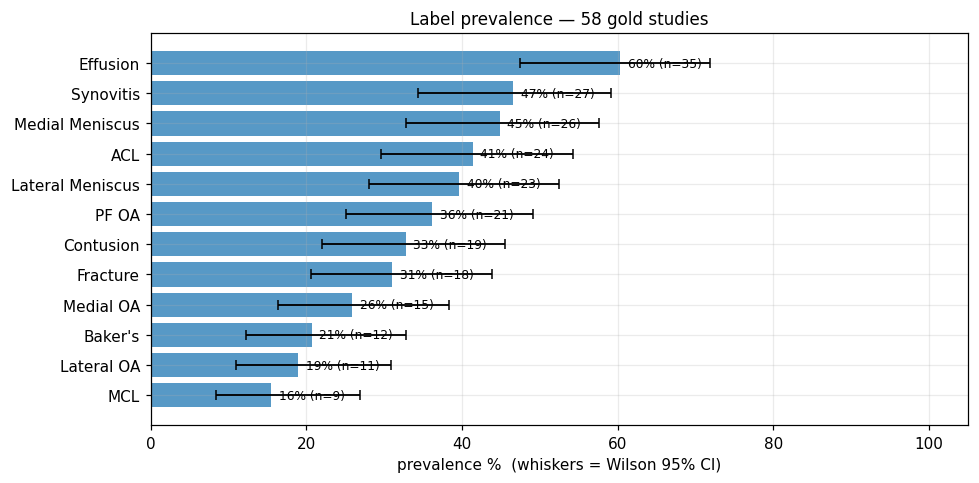

Effective sample size vs. rarest class: MCL has 9 positives. A per-class AUC CI will be huge — aggregate metric hides this.


In [3]:
def wilson(k, n, z=1.959964):
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = z * math.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return center - half, center + half

prev = pd.DataFrame({'k': labeled[LABELS].sum(), 'n': len(labeled)})
prev['p'] = prev.k / prev.n
ci = prev.apply(lambda r: wilson(r.k, r.n), axis=1)
prev['lo'] = [c[0] for c in ci]; prev['hi'] = [c[1] for c in ci]
prev = prev.sort_values('p')

fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(prev))
ax.barh(y, prev.p * 100, alpha=0.75)
ax.errorbar(prev.p * 100, y,
            xerr=[(prev.p - prev.lo) * 100, (prev.hi - prev.p) * 100],
            fmt='none', ecolor='black', elinewidth=1.2, capsize=3)
for i, (p, k) in enumerate(zip(prev.p, prev.k)):
    ax.text(p * 100 + 1, i, f'{p:.0%} (n={int(k)})', va='center', fontsize=8)
ax.set_yticks(y, prev.index)
ax.set_xlabel('prevalence %  (whiskers = Wilson 95% CI)')
ax.set_title(f'Label prevalence — {len(labeled)} gold studies')
ax.set_xlim(0, 105)
plt.tight_layout(); plt.show()

print('Effective sample size vs. rarest class: MCL has', int(prev.loc['MCL','k']), 'positives.',
      'A per-class AUC CI will be huge — aggregate metric hides this.')

### 1.2 Multi-label structure: cardinality, density, label-set entropy

label cardinality (mean positives/study): 4.14
label density     (cardinality / 12)    : 0.34
distinct label sets: 54 / 58 studies | entropy = 3.96 nats
most common combos:
    2×  ['ACL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's"]
    2×  ['ACL', 'Medial Meniscus', 'Lateral Meniscus', 'Effusion', 'Synovitis', 'Contusion', 'Fracture']
    2×  ['MCL']
    2×  ['ACL', 'Medial Meniscus', 'Effusion']
    1×  ['PF OA', 'Effusion']


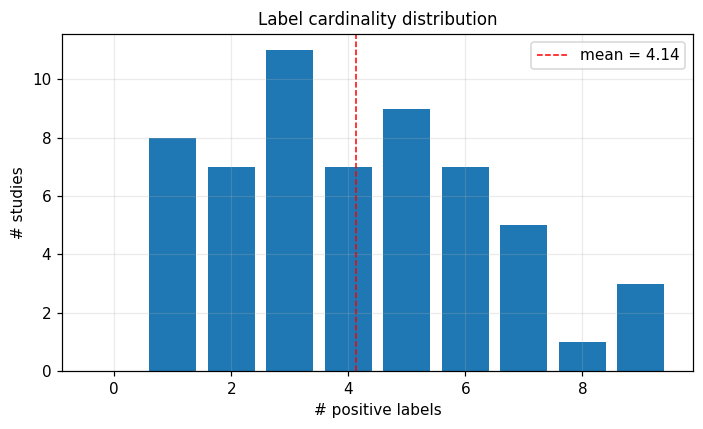

In [4]:
n_pos = Y.sum(axis=1)
card = n_pos.mean()
dens = card / N_CLASSES

combos = Counter(map(tuple, Y.tolist()))
ent = stats.entropy(np.array(list(combos.values())))

print(f'label cardinality (mean positives/study): {card:.2f}')
print(f'label density     (cardinality / 12)    : {dens:.2f}')
print(f'distinct label sets: {len(combos)} / {len(labeled)} studies | entropy = {ent:.2f} nats')
print('most common combos:')
for combo, cnt in combos.most_common(5):
    names = [LABELS[i] for i, b in enumerate(combo) if b]
    print(f'  {cnt:3d}×  {names}')

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(n_pos, bins=np.arange(-0.5, n_pos.max() + 1.5), rwidth=0.8)
ax.axvline(card, color='r', ls='--', lw=1, label=f'mean = {card:.2f}')
ax.set_xlabel('# positive labels'); ax.set_ylabel('# studies')
ax.set_title('Label cardinality distribution')
ax.legend()
plt.tight_layout(); plt.show()

### 1.3 Co-occurrence: counts, lift, Cramér's V

Raw counts flatter pairs of common labels. **Lift** = P(A∩B)/P(A)P(B) (>1 = co-occur more than chance); **Cramér's V** gives a symmetric strength. Worth knowing which pairs the model gets almost for free via correlation.

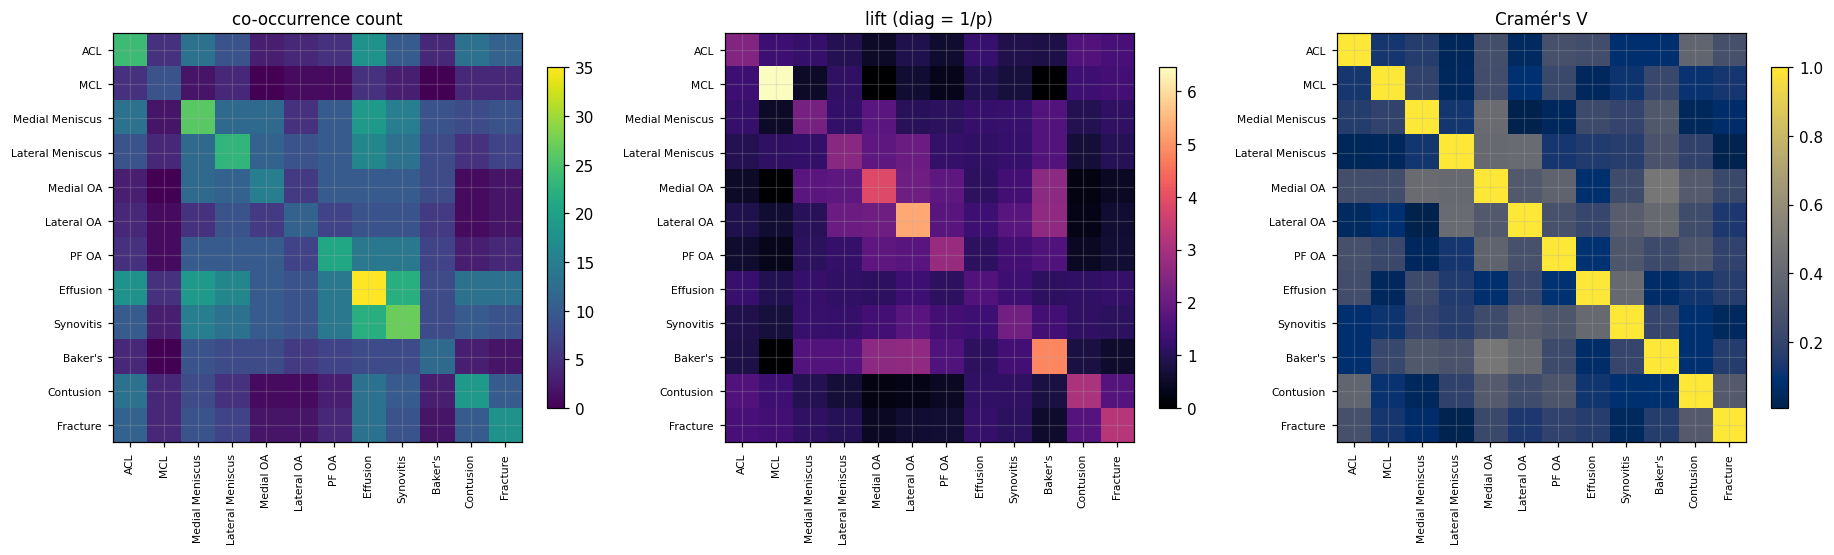

Top associated pairs (V, lift, co-count):
  V=0.48 lift= 2.6 n= 8   Medial OA × Baker's
  V=0.42 lift= 1.8 n=12   Medial Meniscus × Medial OA
  V=0.42 lift= 2.1 n= 9   Lateral Meniscus × Lateral OA
  V=0.41 lift= 1.8 n=11   Lateral Meniscus × Medial OA
  V=0.40 lift= 2.6 n= 6   Lateral OA × Baker's
  V=0.40 lift= 1.4 n=22   Effusion × Synovitis
  V=0.38 lift= 1.7 n=13   ACL × Contusion
  V=0.37 lift= 1.8 n=10   Medial OA × PF OA


In [5]:
n = len(labeled)
co = labeled[LABELS].T.dot(labeled[LABELS]).values.astype(float)
p = Y.mean(axis=0)
exp = np.outer(p, p) * n
lift = co / np.maximum(exp, 1e-9)

V = np.zeros((N_CLASSES, N_CLASSES))
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        a = Y[:, i]; b = Y[:, j]
        tab = np.array([[((a==1)&(b==1)).sum(), ((a==1)&(b==0)).sum()],
                        [((a==0)&(b==1)).sum(), ((a==0)&(b==0)).sum()]])
        V[i, j] = cramers_v(tab)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, M, title, cmap in [
        (axes[0], co, 'co-occurrence count', 'viridis'),
        (axes[1], lift, 'lift (diag = 1/p)', 'magma'),
        (axes[2], V, "Cramér's V", 'cividis')]:
    im = ax.imshow(M, cmap=cmap)
    ax.set_xticks(range(N_CLASSES), LABELS, rotation=90, fontsize=7)
    ax.set_yticks(range(N_CLASSES), LABELS, fontsize=7)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

iu = np.triu_indices(N_CLASSES, 1)
top = sorted(zip(V[iu], lift[iu], co[iu], [LABELS[i] for i in iu[0]], [LABELS[j] for j in iu[1]]),
             reverse=True)
print('Top associated pairs (V, lift, co-count):')
for v, l, c, a, b in top[:8]:
    print(f'  V={v:.2f} lift={l:4.1f} n={int(c):2d}   {a} × {b}')

### 1.4 Do we even have negatives? — per-class balance

AUC needs both classes present. Checking nothing is all-positive/all-negative in the gold set, and how badly a grouped CV split starves rare classes.

In [6]:
bal = pd.DataFrame({'pos': Y.sum(0), 'neg': (1 - Y).sum(0)}, index=LABELS)
bal['pos_rate'] = bal.pos / len(labeled)
bal['min_class'] = bal[['pos', 'neg']].min(axis=1)
print(bal.sort_values('min_class').to_string())
print()
print('Any class with <3 positives or <3 negatives:', (bal.min_class < 3).any())
print('In a 5-fold grouped CV (~11-12 studies/val), expected val positives for rarest class:',
      f"{bal.pos.min() / 5:.1f} — per-fold AUC for MCL will be noisy/meaningless; aggregate over folds or use all 58 for final.")

                  pos  neg  pos_rate  min_class
MCL                 9   49  0.155172          9
Lateral OA         11   47  0.189655         11
Baker's            12   46  0.206897         12
Medial OA          15   43  0.258621         15
Fracture           18   40  0.310345         18
Contusion          19   39  0.327586         19
PF OA              21   37  0.362069         21
Lateral Meniscus   23   35  0.396552         23
Effusion           35   23  0.603448         23
ACL                24   34  0.413793         24
Medial Meniscus    26   32  0.448276         26
Synovitis          27   31  0.465517         27

Any class with <3 positives or <3 negatives: False
In a 5-fold grouped CV (~11-12 studies/val), expected val positives for rarest class: 1.8 — per-fold AUC for MCL will be noisy/meaningless; aggregate over folds or use all 58 for final.


## 2. Reports — the weak-label goldmine (4407 free-text, many languages)

The only supervision for 98.7% of studies. Profiling: language mix, length, duplication/template-ness, and crude per-class keyword hit rates.

chars : mean  1098 | p5  205 | p50  977 | p95  2453 | max  4743
words : mean   148 | p50  129 | max  690


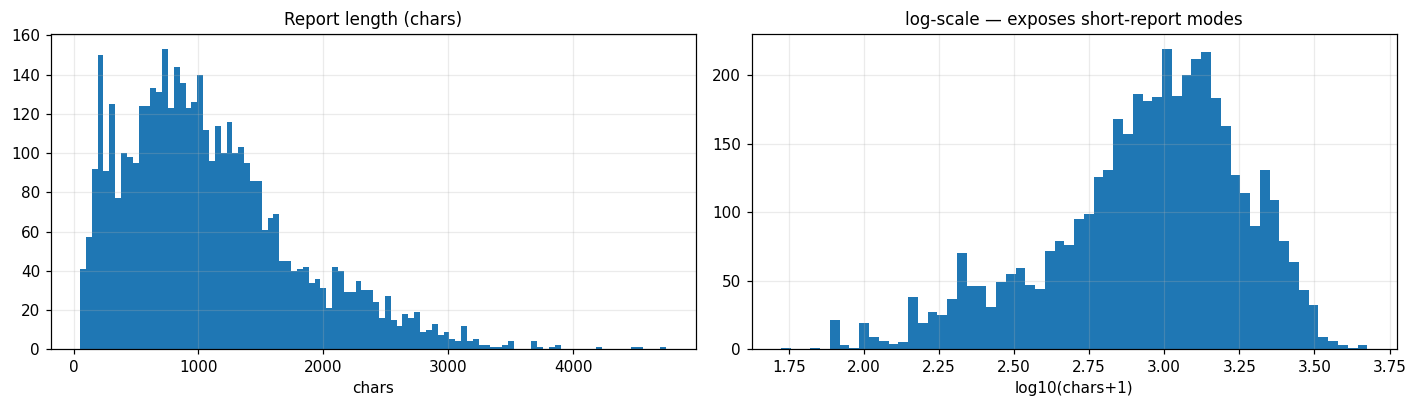

In [7]:
rep = train['Report'].fillna('')
rep_len = rep.str.len()
rep_words = rep.str.split().str.len()

print('chars : mean %5.0f | p5 %4.0f | p50 %4.0f | p95 %5.0f | max %5d' % (
    rep_len.mean(), rep_len.quantile(.05), rep_len.median(), rep_len.quantile(.95), rep_len.max()))
print('words : mean %5.0f | p50 %4.0f | max %4d' % (
    rep_words.mean(), rep_words.median(), rep_words.max()))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].hist(rep_len, bins=100)
axes[0].set_xlabel('chars'); axes[0].set_title('Report length (chars)')
axes[1].hist(np.log10(rep_len + 1), bins=60)
axes[1].set_xlabel('log10(chars+1)'); axes[1].set_title('log-scale — exposes short-report modes')
plt.tight_layout(); plt.show()

### 2.1 Language distribution — heuristic guess

Cheap heuristic (script detection + stopword votes) — take it as indicative only. `de`/`la` collide across Romance languages; the real pipeline should use langdetect or an LLM.

Report
en             1735
other           971
tr              539
es              470
de              250
ru/cyrillic     220
nl              144
fr               78


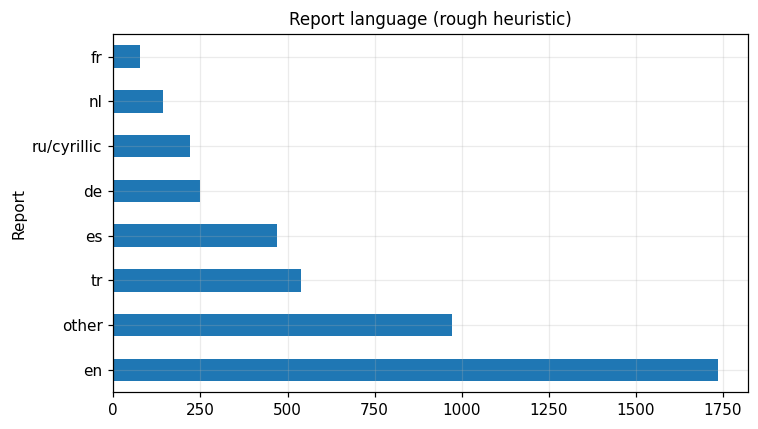

In [8]:
def guess_lang(s: str) -> str:
    if not s:
        return 'none'
    probe = s[:3000]
    if any('CYRILLIC' in unicodedata.name(c, '') for c in probe):
        return 'ru/cyrillic'
    if any('\u4e00' <= c <= '\u9fff' for c in probe):
        return 'zh'
    if any('\u0600' <= c <= '\u06ff' for c in probe):
        return 'ar'
    sl = ' ' + s.lower() + ' '
    hits = {
        'es': len(re.findall(r'\b(rodilla|que|del|las|con|una|hay)\b', sl)),
        'de': len(re.findall(r'\b(der|die|und|mit|des|knie|ein|ist)\b', sl)),
        'fr': len(re.findall(r'\b(genou|les|des|une|avec|est|pas)\b', sl)),
        'tr': len(re.findall(r'\b(diz|ve|ile|bir|için|olan|eklem)\b', sl)),
        'pt': len(re.findall(r'\b(joelho|das|dos|com|uma|para|não)\b', sl)),
        'nl': len(re.findall(r'\b(het|een|van|met|voor|knie|zijn)\b', sl)),
        'it': len(re.findall(r'\b(ginocchio|della|che|con|per|una)\b', sl)),
        'en': len(re.findall(r'\b(the|and|of|with|there|knee|joint)\b', sl)),
    }
    best = max(hits, key=hits.get)
    return best if hits[best] >= 3 else 'other'

lang = rep.map(guess_lang)
lang_counts = lang.value_counts()
print(lang_counts.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
lang_counts.plot.barh(ax=ax)
ax.set_title('Report language (rough heuristic)')
plt.tight_layout(); plt.show()

### 2.2 Template-ness / duplication

If lots of reports are near-duplicates (same clinic template), the effective diversity of the weak-label corpus is well under 4407. Cheap proxy: exact dup rate + dup rate of the normalized first 200 chars.

In [9]:
def normalize_txt(s):
    s = unicodedata.normalize('NFKD', s).lower()
    s = re.sub(r'\[date\]|\[.*?\]', ' ', s)
    s = re.sub(r'\W+', ' ', s)
    return s.strip()

exact_dup = rep.duplicated().sum()
head200 = rep.map(lambda s: normalize_txt(s)[:200])
head_dup = head200.duplicated().sum()
uniq_heads = head200.nunique()

print(f'exact duplicate reports         : {exact_dup} ({exact_dup/len(rep):.1%})')
print(f'duplicate normalized 200-ch head: {head_dup} ({head_dup/len(rep):.1%})  | unique heads: {uniq_heads}')

top_heads = head200.value_counts().head(5)
print('\nmost common report openings (normalized):')
for h, c in top_heads.items():
    print(f'  {c:3d}×  {h[:90]!r}')

exact duplicate reports         : 131 (3.0%)
duplicate normalized 200-ch head: 435 (9.9%)  | unique heads: 3972

most common report openings (normalized):
   37×  'diz eklemi ic i sıvı miktarı normal c apraz ve yan bag lar normal medyal ve lateral menisk'
   33×  'in the medial compartment the meniscus is not torn and there is no focal chondrosis or cho'
   21×  'te cnica rmn de la rodilla resultados pinzamiento de la almohadilla grasa de hoffa impresi'
   19×  'exam type mri knee right wo contrast exam date and time indication right knee pain compari'
   15×  'te cnica rmn de la rodilla resultados sin anomali as impresio n sin anomali as'


### 2.3 Keyword probe — how much weak signal is even there?

Per-class multilingual keyword lists. Hit rate = fraction of reports with at least one keyword for the class. **Not the label** — negation/context ignored — but it bounds what a keyword miner can see, and flags classes that barely show up in text.

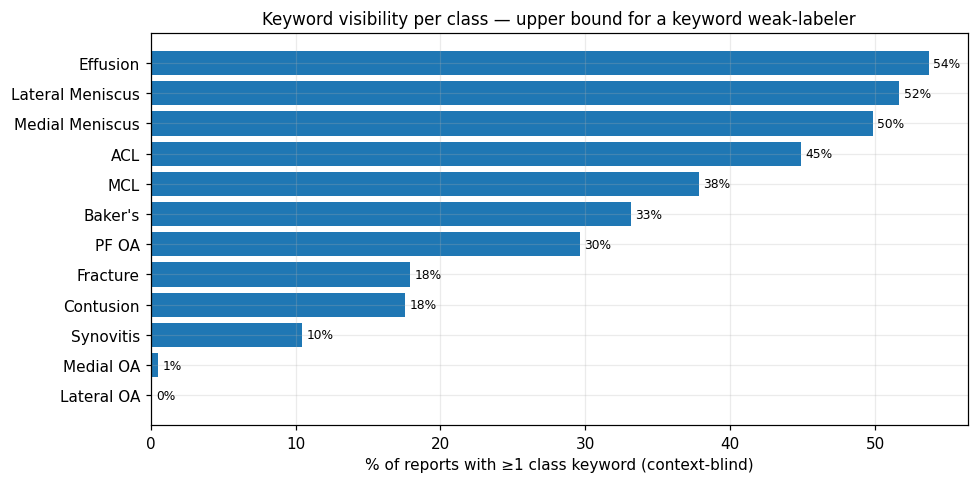

classes with <5% keyword visibility — these need synonyms/LLM mining or will be invisible:
['Lateral OA', 'Medial OA']


In [10]:
KEYWORDS = {
    'ACL':             ['acl', 'ligamento cruzado anterior', 'vorderes kreuzband', 'ligament croisé antérieur',
                        'ön çapraz bağ', 'anterior cruciate'],
    'MCL':             ['mcl', 'ligamento colateral medial', 'mediales kollateralband', 'ligament collatéral médial',
                        'iç yan bağ', 'medial collateral'],
    'Medial Meniscus': ['menisco medial', 'menisco interno', 'innenmeniskus', 'ménisque médial',
                        'medial menisküs', 'medial meniscus'],
    'Lateral Meniscus':['menisco lateral', 'außenmeniskus', 'ménisque latéral', 'lateral menisküs',
                        'lateral meniscus'],
    'Medial OA':       ['artrosis femorotibial medial', 'gonarthrose medial', 'medial osteoarthritis',
                        'medial compartment osteoarthritis'],
    'Lateral OA':      ['artrosis femorotibial lateral', 'gonarthrose lateral', 'lateral osteoarthritis'],
    'PF OA':           ['femoropatelar', 'patellofemoral', 'retropatellararthrose', 'fémoropatellaire'],
    'Effusion':        ['derrame', 'effusion', 'erguss', 'épanchement', 'efüzyon', 'joint fluid'],
    'Synovitis':       ['sinovitis', 'synovitis', 'synovialitis', 'synovite', 'sinovit'],
    "Baker's":        ['baker', 'popliteal cyst', 'quiste de baker', 'bakersche zyste', 'kyste de baker'],
    'Contusion':       ['contusion', 'contusión', 'prellung', 'bone bruise', 'ödeme óseo', 'edema oseo'],
    'Fracture':        ['fractura', 'fraktur', 'fracture', 'kırık', 'broken'],
}

rep_l = rep.str.lower()
hits = pd.DataFrame({c: rep_l.map(lambda s, kws=kws: any(k in s for k in kws))
                     for c, kws in KEYWORDS.items()})

hit_rate = hits.mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(hit_rate.index, hit_rate.values * 100)
for i, v in enumerate(hit_rate.values * 100):
    ax.text(v + 0.3, i, f'{v:.0f}%', va='center', fontsize=8)
ax.set_xlabel('% of reports with ≥1 class keyword (context-blind)')
ax.set_title('Keyword visibility per class — upper bound for a keyword weak-labeler')
plt.tight_layout(); plt.show()

print('classes with <5% keyword visibility — these need synonyms/LLM mining or will be invisible:')
print(list(hit_rate[hit_rate < 0.05].index))

### 2.4 Keyword-vs-gold sanity check

On the 58 gold studies we can actually score the keyword probe against truth. n is tiny so it's noisy, but a keyword set whose recall is ~0 on gold is definitely broken.

In [11]:
gold_hits = hits.loc[labeled.index].values
rows = []
for i, c in enumerate(LABELS):
    y = Y[:, i]; h = gold_hits[:, i]
    tp = int(((y==1)&(h==1)).sum()); fp = int(((y==0)&(h==1)).sum())
    fn = int(((y==1)&(h==0)).sum()); tn = int(((y==0)&(h==0)).sum())
    rec = tp / max(tp+fn, 1); prec = tp / max(tp+fp, 1)
    rows.append({'class': c, 'gold_pos': int(y.sum()), 'kw_hit': int(h.sum()),
                 'kw_recall': round(rec, 2), 'kw_prec': round(prec, 2),
                 'tp': tp, 'fp': fp, 'fn': fn})
kw_eval = pd.DataFrame(rows).set_index('class')
print(kw_eval.to_string())
print()
print('Caveat: n=58, and keyword lists are v1 — low recall mostly means missing synonyms,',
      'and low precision often reflects negation ("no effusion") we ignore here.')

                  gold_pos  kw_hit  kw_recall  kw_prec  tp  fp  fn
class                                                             
ACL                     24      32       0.58     0.44  14  18  10
MCL                      9      26       0.67     0.23   6  20   3
Medial Meniscus         26      36       0.69     0.50  18  18   8
Lateral Meniscus        23      34       0.74     0.50  17  17   6
Medial OA               15       0       0.00     0.00   0   0  15
Lateral OA              11       0       0.00     0.00   0   0  11
PF OA                   21      16       0.19     0.25   4  12  17
Effusion                35      39       0.63     0.56  22  17  13
Synovitis               27      15       0.41     0.73  11   4  16
Baker's                 12      18       0.67     0.44   8  10   4
Contusion               19      17       0.47     0.53   9   8  10
Fracture                18      16       0.44     0.50   8   8  10

Caveat: n=58, and keyword lists are v1 — low recall mostly me

## 3. Series metadata — what the model actually sees

24,371 series across 4407 studies. Each study is a bag of series; the model has to aggregate across planes/weightings.

series rows          : 24371
series/study         : mean 5.53 | min 3 | max 14
Fluid==FatSuppression: True  -> single "sequence-type" flag


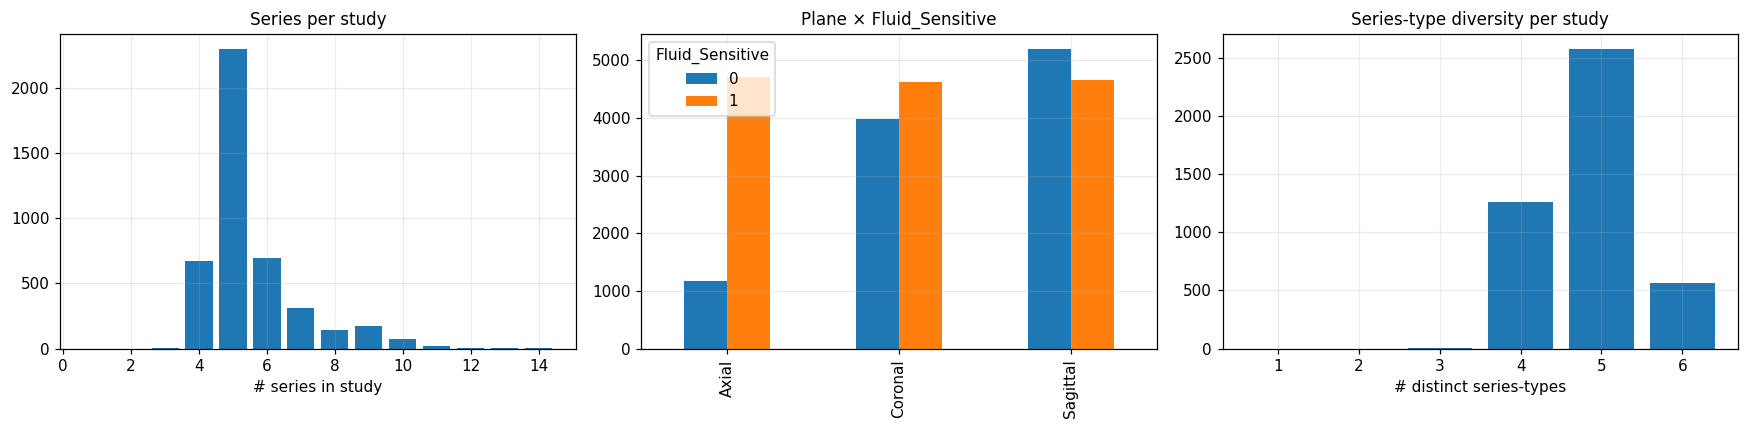


Series-type mix (plane × fluid-sensitive):
stype
Sag-FS    5197
Axi+FS    4719
Sag+FS    4667
Cor+FS    4624
Cor-FS    3985
Axi-FS    1179


In [12]:
ts = pd.read_csv(DATA / 'train_series.csv')
per_study = ts.groupby('StudyInstanceUID').size()

print(f'series rows          : {len(ts)}')
print(f'series/study         : mean {per_study.mean():.2f} | min {per_study.min()} | max {per_study.max()}')
print(f'Fluid==FatSuppression: {(ts.Fluid_Sensitive == ts.Fat_Suppression).all()}  -> single "sequence-type" flag')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(per_study, bins=np.arange(0.5, per_study.max()+1.5), rwidth=0.8)
axes[0].set_xlabel('# series in study'); axes[0].set_title('Series per study')

pd.crosstab(ts.Anatomical_Plane, ts.Fluid_Sensitive).plot.bar(ax=axes[1])
axes[1].set_title('Plane × Fluid_Sensitive'); axes[1].set_xlabel('')

ts['stype'] = ts.Anatomical_Plane.str[:3] + np.where(ts.Fluid_Sensitive==1, '+FS', '-FS')
cover = ts.groupby('StudyInstanceUID')['stype'].nunique()
axes[2].hist(cover, bins=np.arange(0.5, cover.max()+1.5), rwidth=0.8)
axes[2].set_xlabel('# distinct series-types'); axes[2].set_title('Series-type diversity per study')
plt.tight_layout(); plt.show()

print('\nSeries-type mix (plane × fluid-sensitive):')
print(ts.stype.value_counts().to_string())

In [13]:
pivot = ts.pivot_table(index='Anatomical_Plane', columns='Fluid_Sensitive',
                       values='SeriesInstanceUID', aggfunc='count').fillna(0).astype(int)
print('Series count by plane × fluid:')
print(pivot)

planes_per_study = ts.groupby('StudyInstanceUID')['Anatomical_Plane'].agg(lambda s: set(s))
have_all3 = planes_per_study.map(lambda s: {'Sagittal','Coronal','Axial'} <= set(s)).mean()
print(f'\nstudies with all 3 planes: {have_all3:.1%}')
print('plane-set distribution:')
print(planes_per_study.map(lambda s: '+'.join(sorted(x[:3] for x in s))).value_counts().head(8).to_string())

Series count by plane × fluid:
Fluid_Sensitive      0     1
Anatomical_Plane            
Axial             1179  4719
Coronal           3985  4624
Sagittal          5197  4667

studies with all 3 planes: 100.0%
plane-set distribution:
Anatomical_Plane
Axi+Cor+Sag    4407


## 4. DICOM pixels & headers — a few series, in detail

DICOM helpers inlined below so this runs standalone on Kaggle. We look at:

- **Geometry sanity**: does `Anatomical_Plane` agree with `ImageOrientationPatient`? (spoiler: yes, and the slices are slightly oblique)
- **Acquisition params**: TR/TE/ETL/flip — can we read weighting off the headers?
- **Foreground/background**: how much of the FOV is air (zeros)? — relevant to the efficiency prize
- **Slice spacing**: thickness vs. spacing (the gap)

In [14]:
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut

def load_dicom_pixel(path):
    """pixel array (float32) + dataset, with VOI LUT + rescale applied."""
    ds = pydicom.dcmread(str(path))
    arr = ds.pixel_array
    try:
        arr = apply_voi_lut(arr, ds)
    except Exception:
        pass
    arr = arr.astype(np.float32)
    slope = float(getattr(ds, 'RescaleSlope', 1.0) or 1.0)
    intercept = float(getattr(ds, 'RescaleIntercept', 0.0) or 0.0)
    return arr * slope + intercept, ds

def series_files(series_dir):
    p = Path(series_dir)
    return sorted([f for f in p.iterdir() if f.suffix.lower() == '.dcm'])

def load_series_volume(series_dir):
    """stack slices into (D,H,W) float32, sorted by position on slice normal."""
    files = series_files(series_dir)
    if not files:
        return None, []
    slices, keys, dss = [], [], []
    for f in files:
        try:
            arr, ds = load_dicom_pixel(f)
        except Exception:
            continue
        if arr.ndim == 3:
            arr = arr[0] if arr.shape[0] < arr.shape[-1] else arr[..., 0]
        slices.append(arr)
        ipp = getattr(ds, 'ImagePositionPatient', None)
        iop = getattr(ds, 'ImageOrientationPatient', None)
        if ipp is not None and iop is not None:
            iop = np.asarray([float(x) for x in iop])
            normal = np.cross(iop[:3], iop[3:])
            keys.append(float(np.dot(np.asarray([float(x) for x in ipp]), normal)))
        else:
            keys.append(float(getattr(ds, 'InstanceNumber', 0) or 0))
        dss.append(ds)
    if not slices:
        return None, []
    order = np.argsort(keys)
    vol = np.stack([slices[i] for i in order], axis=0).astype(np.float32)
    return vol, [dss[i] for i in order]

def robust_normalize(vol, lo=0.5, hi=99.5):
    """percentile-clip + scale to [0,1] — robust across vendors/field strengths."""
    v = vol[np.isfinite(vol)]
    if v.size == 0:
        return np.zeros_like(vol, dtype=np.float32)
    a, b = np.percentile(v, [lo, hi])
    if b <= a:
        b = a + 1e-6
    return np.clip((vol - a) / (b - a), 0, 1).astype(np.float32)

print('dicom helpers ready')

dicom helpers ready


In [15]:
# find a few series of DICOMs. The layout is <DATA>/test_series/<study>/<series>/*.dcm both
# on Kaggle and locally, so the same walk works — on the full train set we'd point this at train_series/.
def find_series_dirs(root, min_files=5, limit=3):
    hits = {}
    for f in Path(root).rglob('*.dcm'):
        hits[f.parent] = hits.get(f.parent, 0) + 1
    dirs = [d for d, c in hits.items() if c >= min_files]
    return sorted(dirs)[:limit]

series_dirs = find_series_dirs(DATA / 'test_series', limit=3)
# fall back to train_series/ if test_series is empty (e.g. full data locally)
if not series_dirs and (DATA / 'train_series').exists():
    series_dirs = find_series_dirs(DATA / 'train_series', limit=3)

print(f'{len(series_dirs)} series to inspect')
for d in series_dirs:
    print(' ', d.relative_to(DATA), f'({len(list(d.glob("*.dcm")))} dicoms)')

3 series to inspect
  test_series/1.2.826.0.1.3680043.8.498.10047035057544427318018579121635276191/1.2.826.0.1.3680043.8.498.11580656442259111255675562605155903947 (34 dicoms)
  test_series/1.2.826.0.1.3680043.8.498.10047035057544427318018579121635276191/1.2.826.0.1.3680043.8.498.17811502614030631664517622518906646132 (30 dicoms)
  test_series/1.2.826.0.1.3680043.8.498.10047035057544427318018579121635276191/1.2.826.0.1.3680043.8.498.30565395595045942404081022062489758495 (30 dicoms)


In [16]:
def plane_from_iop(iop):
    """geometric plane from row/col direction cosines: which axis the slice normal follows."""
    iop = np.asarray([float(x) for x in iop])
    normal = np.cross(iop[:3], iop[3:])
    idx = int(np.argmax(np.abs(normal)))
    return ['Sagittal', 'Coronal', 'Axial'][idx], normal

rows = []
volumes = {}
for d in series_dirs:
    vol, dss = load_series_volume(d)
    if vol is None: continue
    name = str(d)
    volumes[name] = vol
    ds0 = dss[0]
    iop = getattr(ds0, 'ImageOrientationPatient', None)
    geom, normal = plane_from_iop(iop) if iop is not None else ('?', None)
    thick = float(getattr(ds0, 'SliceThickness', np.nan) or np.nan)
    space = float(getattr(ds0, 'SpacingBetweenSlices', np.nan) or np.nan)
    rows.append({
        'series': name[-50:], 'slices': vol.shape[0], 'H': vol.shape[1], 'W': vol.shape[2],
        'SeriesDesc': str(getattr(ds0, 'SeriesDescription', '')),
        'geom_plane': geom,
        'normal': None if normal is None else np.round(normal, 2).tolist(),
        'pix_mm': [round(float(x),4) for x in getattr(ds0, 'PixelSpacing', [np.nan,np.nan])],
        'thick_mm': thick, 'space_mm': space, 'gap_mm': round(space-thick, 2),
        'TR': float(getattr(ds0, 'RepetitionTime', np.nan) or np.nan),
        'TE': float(getattr(ds0, 'EchoTime', np.nan) or np.nan),
        'ETL': int(getattr(ds0, 'EchoTrainLength', 0) or 0),
        'flip': float(getattr(ds0, 'FlipAngle', np.nan) or np.nan),
        'field_T': float(getattr(ds0, 'MagneticFieldStrength', np.nan) or np.nan),
        'model': str(getattr(ds0, 'ManufacturerModelName', '')),
        'coil': str(getattr(ds0, 'ReceiveCoilName', '')),
        'bg_frac': round(float((vol == 0).mean()), 3),
        'p99.9': int(np.percentile(vol, 99.9)), 'max': int(vol.max()),
    })

meta = pd.DataFrame(rows)
with pd.option_context('display.max_colwidth', 55):
    display(meta)

,series,slices,H,W,SeriesDesc,geom_plane,normal,pix_mm,thick_mm,space_mm,gap_mm,TR,TE,ETL,flip,field_T,model,coil,bg_frac,p99.9,max
0,80043.8.498.11580656442259111255675562605155903947,34,960,960,pd_tse_tra_d,Axial,"[-0.06, 0.04, 1.0]","[0.1562, 0.1562]",3.0,3.3,0.3,3000.0,46.0,6,180.0,1.5,MAGNETOM Avanto fit,TxRx_Knee_15,0.123,4095,4095
1,80043.8.498.17811502614030631664517622518906646132,30,800,800,t2_tse_sag_d,Sagittal,"[-0.99, 0.16, -0.01]","[0.1875, 0.1875]",3.0,3.3,0.3,5000.0,91.0,13,180.0,1.5,MAGNETOM Avanto fit,TxRx_Knee_15,0.191,3873,4095
2,80043.8.498.30565395595045942404081022062489758495,30,896,896,pd_tse_sag_d,Sagittal,"[-0.99, 0.16, -0.01]","[0.1674, 0.1674]",3.0,3.3,0.3,3000.0,8.8,7,180.0,1.5,MAGNETOM Avanto fit,TxRx_Knee_15,0.188,4095,4095


### 4.1 Slice mosaics + central-slice detail

Note the big black FOV margins and (in sagittal views) how little of the frame is knee. An ROI crop is basically free accuracy-per-FLOP.

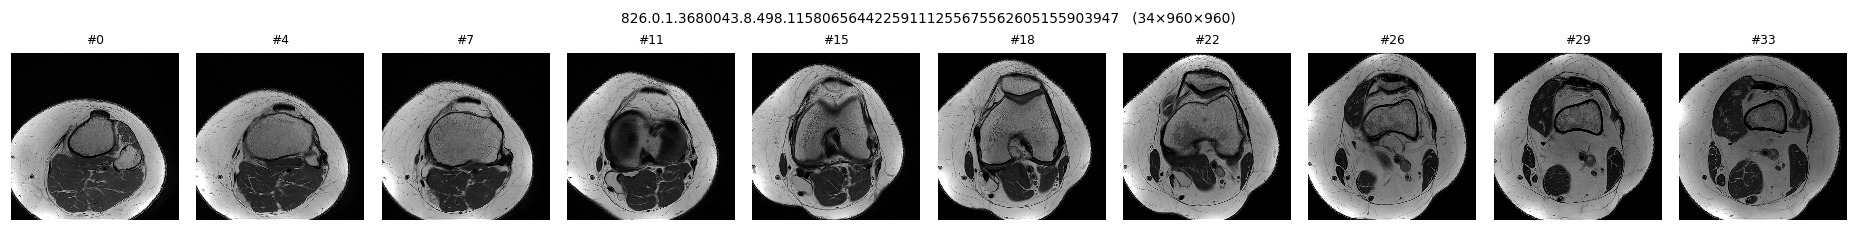

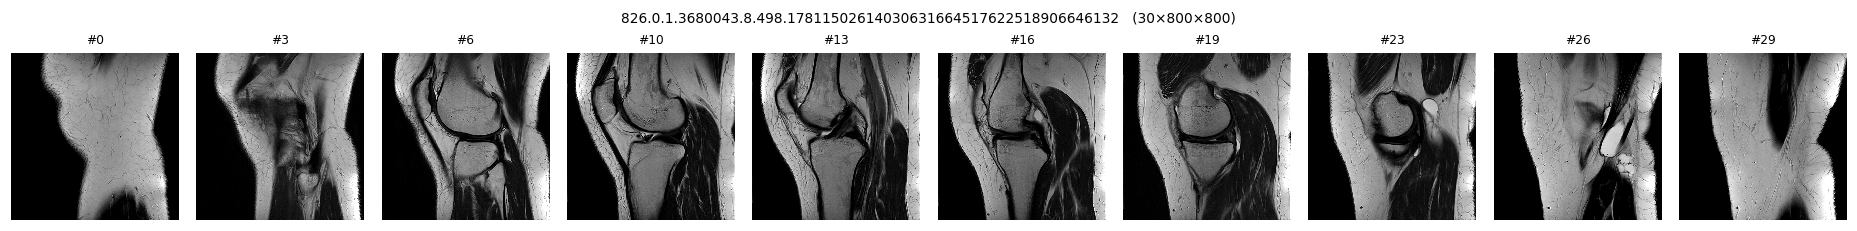

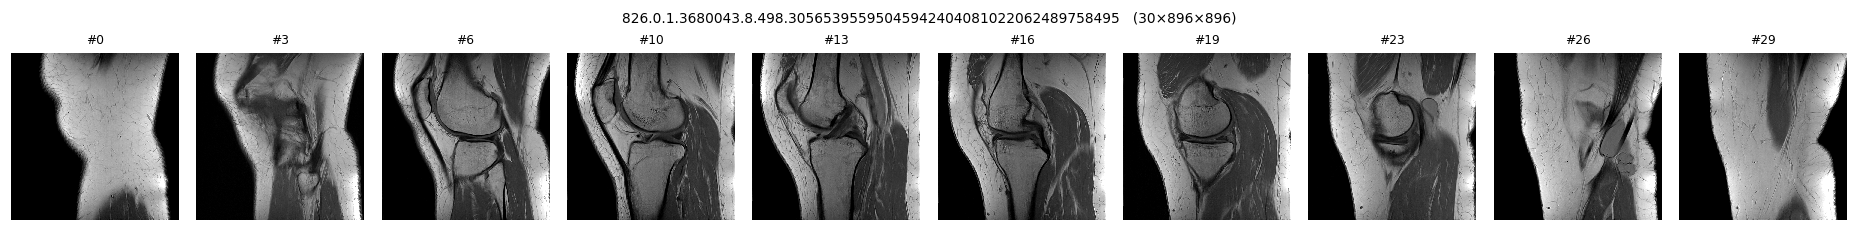

In [17]:
for name, vol in volumes.items():
    vn = robust_normalize(vol)
    D = vn.shape[0]
    idx = np.linspace(0, D-1, min(10, D)).round().astype(int)
    fig, axes = plt.subplots(1, len(idx), figsize=(17, 2.1))
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(vn[i], cmap='gray', interpolation='nearest')
        ax.set_title(f'#{i}', fontsize=8); ax.axis('off')
    fig.suptitle(f'{name[-60:]}   ({vol.shape[0]}×{vol.shape[1]}×{vol.shape[2]})', fontsize=9)
    plt.tight_layout(); plt.show()

80043.8.498.11580656442259111255675562605155903947  foreground=70.8%  bbox=(np.int64(1), np.int64(1), np.int64(958), np.int64(959))  crop-side≈958px
80043.8.498.17811502614030631664517622518906646132  foreground=82.1%  bbox=(np.int64(1), np.int64(0), np.int64(799), np.int64(799))  crop-side≈799px
80043.8.498.30565395595045942404081022062489758495  foreground=84.2%  bbox=(np.int64(1), np.int64(0), np.int64(895), np.int64(895))  crop-side≈895px


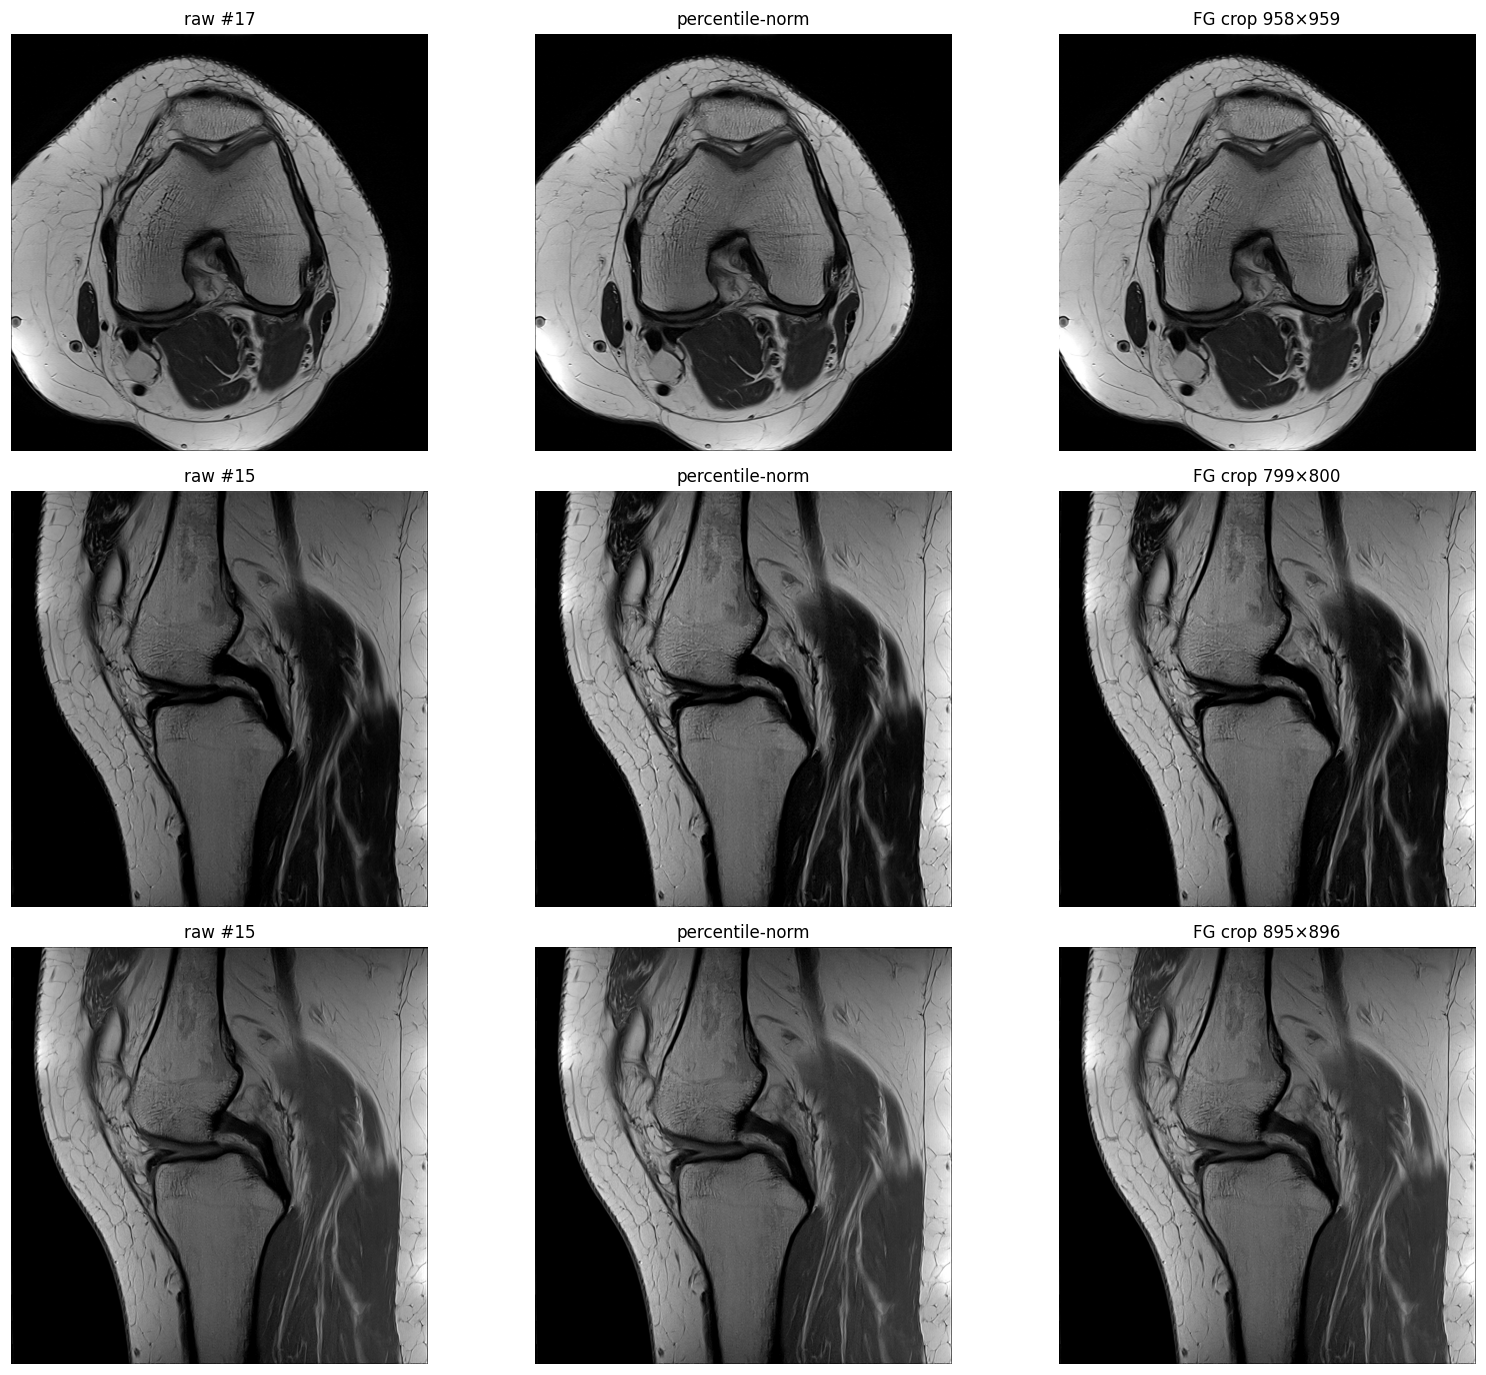

In [18]:
fig = plt.figure(figsize=(15, 4.2 * len(volumes)))
gs = GridSpec(len(volumes), 3, figure=fig)

for r, (name, vol) in enumerate(volumes.items()):
    mid = vol.shape[0] // 2
    raw = vol[mid]
    norm = robust_normalize(vol)[mid]
    mask = raw > 0.01 * raw.max()
    ys, xs = np.where(mask)
    bbox = (xs.min(), ys.min(), xs.max(), ys.max()) if len(xs) else (0,0,raw.shape[1]-1, raw.shape[0]-1)

    ax0 = fig.add_subplot(gs[r, 0]); ax0.imshow(raw, cmap='gray'); ax0.set_title(f'raw #{mid}')
    ax1 = fig.add_subplot(gs[r, 1]); ax1.imshow(norm, cmap='gray'); ax1.set_title('percentile-norm')
    ax2 = fig.add_subplot(gs[r, 2])
    x0,y0,x1,y1 = bbox
    ax2.imshow(norm[y0:y1+1, x0:x1+1], cmap='gray'); ax2.set_title(f'FG crop {x1-x0+1}×{y1-y0+1}')
    for ax in (ax0, ax1, ax2): ax.axis('off')
    fg = mask.mean()
    ax0.set_ylabel(name.split('/')[-1][:24], fontsize=7, rotation=0, labelpad=60, va='center')
    print(f'{name[-50:]}  foreground={fg:.1%}  bbox={bbox}  crop-side≈{max(x1-x0, y1-y0)}px')
plt.tight_layout(); plt.show()

### 4.2 Intensity distributions & normalization

Raw uint16 ranges differ per series; percentile normalization equalizes scale, but watch the **big zero-background mass** — include background in the percentiles and you waste dynamic range on air.

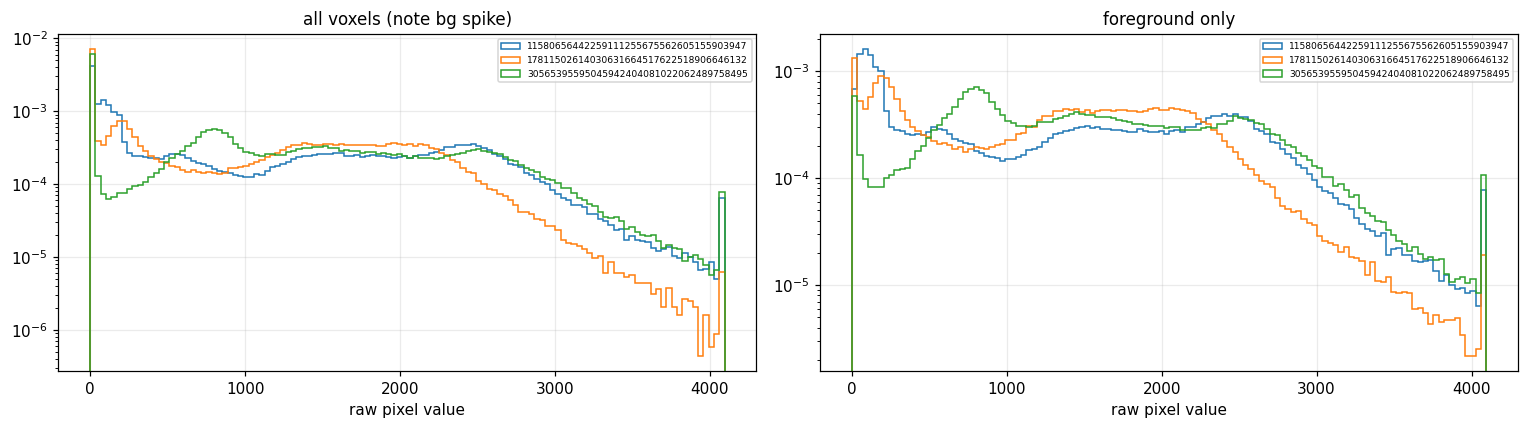

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, vol in volumes.items():
    v = vol.ravel()
    step = max(1, v.size // 200000)
    axes[0].hist(v[::step], bins=120, histtype='step', density=True, label=name[-38:])
    fg = v[v > 0]
    axes[1].hist(fg[::step], bins=120, histtype='step', density=True, label=name[-38:])
axes[0].set_title('all voxels (note bg spike)'); axes[0].set_yscale('log')
axes[1].set_title('foreground only'); axes[1].set_yscale('log')
for ax in axes:
    ax.set_xlabel('raw pixel value')
    h, l = ax.get_legend_handles_labels()
    if h: ax.legend(fontsize=6)
plt.tight_layout(); plt.show()

### 4.3 Geometry check: does `Anatomical_Plane` match `ImageOrientationPatient`?

Inferring the geometric plane from the slice normal and comparing with the CSV label. (On Kaggle we match series by UID against `train_series.csv`/`test_series.csv`.)

In [20]:
test_series = pd.read_csv(DATA / 'test_series.csv')
# on Kaggle the sample dicoms may belong to train or test; join both to look up plane labels
all_series = pd.concat([
    ts.assign(split='train'),
    test_series.assign(split='test'),
], ignore_index=True)

checks = []
for d in series_dirs:
    suid = d.name
    row = all_series[all_series.SeriesInstanceUID == suid]
    vol, dss = load_series_volume(d)
    geom, normal = plane_from_iop(getattr(dss[0], 'ImageOrientationPatient'))
    checks.append({
        'series_uid': suid[-24:],
        'csv_plane': row.Anatomical_Plane.iloc[0] if len(row) else '?',
        'geom_plane': geom,
        'normal_xyz': np.round(normal, 2).tolist(),
        'match': bool(len(row) and row.Anatomical_Plane.iloc[0] == geom),
        'SeriesDesc': str(getattr(dss[0], 'SeriesDescription', '')),
    })
chk = pd.DataFrame(checks)
print(chk.to_string(index=False))
print()
print('obliqueness: normals are not axis-aligned — the scanner prescribed slightly off-axis.',
      'Fine for 2.5D CNNs; matters if you ever resample to a canonical grid.')

              series_uid csv_plane geom_plane           normal_xyz  match   SeriesDesc
111255675562605155903947     Axial      Axial   [-0.06, 0.04, 1.0]   True pd_tse_tra_d
631664517622518906646132  Sagittal   Sagittal [-0.99, 0.16, -0.01]   True t2_tse_sag_d
942404081022062489758495  Sagittal   Sagittal [-0.99, 0.16, -0.01]   True pd_tse_sag_d

obliqueness: normals are not axis-aligned — the scanner prescribed slightly off-axis. Fine for 2.5D CNNs; matters if you ever resample to a canonical grid.


## 5. Test set & submission format

In [21]:
test = pd.read_csv(DATA / 'test.csv')
sub = pd.read_csv(DATA / 'sample_submission.csv')

print('test studies:', len(test), '| test series:', len(test_series))
print('submission: one row per StudyInstanceUID, 12 probability columns')
with pd.option_context('display.max_columns', 15):
    display(sub.head(3))

print('test series per study:')
print(test_series.groupby('StudyInstanceUID').size().to_string())

test studies: 3 | test series: 15
submission: one row per StudyInstanceUID, 12 probability columns


,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
1,1.2.826.0.1.3680043.8.498.10062861783145312629...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
2,1.2.826.0.1.3680043.8.498.10067514707072572280...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5


test series per study:
StudyInstanceUID
1.2.826.0.1.3680043.8.498.10047035057544427318018579121635276191    5
1.2.826.0.1.3680043.8.498.10062861783145312629332250977456991776    5
1.2.826.0.1.3680043.8.498.10067514707072572280263481548497591402    5


## 6. What I'd actually take away from this

**The evaluation is the biggest trap.**
n=58, and the rarest class (MCL) has 9 positives. A 5-fold CV puts ~2 MCL positives in a val fold, so per-fold per-class AUC is basically noise, and every prevalence has a Wilson CI ±10–15 points wide. Pool predictions across folds before computing AUC, report CIs, and don't read anything into a single-split 0.02 gain.

**The keyword weak-labeler (v1) is broken for exactly the classes we care about.**
Scored against the 58 gold studies: all three OA subtypes (Medial/Lateral/PF) get recall = 0 — the multilingual word lists just don't include the phrases radiologists use (e.g. Spanish "artrosis"). Effusion/meniscus are text-visible (recall ~0.6–0.7) but precision is capped by negation we don't handle ("no effusion"). So: keyword mining is at best a positive-precision seed; the real lever is LLM distillation with negation/section awareness. Now there's numbers behind that instead of a hunch.

**Label structure is exploitable, with a caveat.**
~4.1 positives/study, density 0.34, and co-occurrence follows anatomy: meniscus↔same-side OA, Effusion×Synovitis×Baker's (inflammation triad), ACL×Contusion (trauma). A shared multi-label representation should help; the flip side is errors correlate too, so one broken class can drag the aggregate AUC.

**The input side is tidy, and there's a free FLOP win.**
Every study has all 3 planes (100%), `Fluid_Sensitive == Fat_Suppression` always, ~5.5 series/study → one sequence-type flag and a straightforward bag-of-series model. Sample DICOMs: Siemens 1.5T, 15-ch knee coil, ~960×960 uint16 (12-bit stored), ~30 slices, 3.0/3.3mm spacing, TR/TE consistent with PD/T2 TSE. Slices are a few degrees oblique — irrelevant for a 2.5D CNN, only matters if resampling. **~15–20% of voxels are pure background and the knee fills well under half the FOV** → a foreground crop is the cheapest accuracy-per-FLOP available for the efficiency prize.

**The report corpus is smaller than it looks.**
Median ~1k chars, but 3% exact dups and ~10% share a normalized 200-char opening (biggest template cluster appears 37×). Effective diversity < 4407, spread thin across es/de/tr/en/fr/ru/… Quality of mining (LLM, negation) beats chasing coverage.

So the to-do list more or less writes itself:
1. Fix the weak-label miner — synonym expansion + LLM distillation + negation, OA subtypes first (that's the blind spot).
2. Rebuild evaluation around pooled-AUC + bootstrap CIs; stop trusting single folds.
3. Add a foreground bbox crop to the DICOM pipeline (percentile normalization is already there) — nearly free FLOPs.
4. Run the header/pixel scan over the full DICOM set to confirm the plane labels and background fraction hold outside the sample.